In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
%%bash
cp "/groups/xgfabric/rhartung/queue_testing/ahead.csv" "."
cp "/groups/xgfabric/rhartung/queue_testing/times.csv" "."

In [3]:
ahead = pd.read_csv('ahead.csv')
times = pd.read_csv('times.csv')

del ahead['num_cores']

df = pd.merge(times, ahead, on='file')
df['queuing_delay'] = df['started'] - df['submitted']
df['submitted_dt'] = pd.to_datetime(df['submitted'], unit='s') - pd.Timedelta('04:00:00')
df['started_dt'] = pd.to_datetime(df['started'], unit='s') - pd.Timedelta('04:00:00')

# Sort by submission time
df = df.sort_values('submitted_dt')
df.to_csv('combined_data.csv', index=False)

In [4]:
df = df[df['num_cores'] == 64]

In [5]:
# Convert datetime columns if needed
df['submitted_dt'] = pd.to_datetime(df['submitted_dt'])
df['started_dt'] = pd.to_datetime(df['started_dt'])

# Extract time-based features
df['hour'] = df['submitted_dt'].dt.hour
df['day_of_week'] = df['submitted_dt'].dt.dayofweek
df['minute'] = df['submitted_dt'].dt.minute

# Calculate additional features
df['total_jobs'] = df['jobs_ahead'] + df['jobs_in_my_queue'] + df['jobs_running']
df['queue_load'] = df['jobs_ahead'] + df['jobs_in_my_queue']

In [6]:
feature_columns = [
    'num_cores',
    'jobs_ahead',
    'jobs_in_my_queue',
    'jobs_running',
    'hour',
    'day_of_week',
    'minute',
    'total_jobs',
    'queue_load'
]

X = df[feature_columns]
y = df['queuing_delay']

In [7]:
correlations = df[feature_columns + ['queuing_delay']].corr()['queuing_delay'].sort_values(ascending=False)
print(correlations)

queuing_delay       1.000000
hour                0.117346
jobs_in_my_queue    0.097372
queue_load          0.070452
total_jobs          0.070408
jobs_ahead          0.065966
minute             -0.000598
day_of_week        -0.069751
jobs_running       -0.074834
num_cores                NaN
Name: queuing_delay, dtype: float64


In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 8581
Test set size: 2146


In [9]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Support Vector Regression': SVR(kernel='rbf', C=100, gamma='scale'),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

In [10]:
# Train and evaluate models
results = {}
predictions = {}

print("\n" + "="*50)
print("MODEL TRAINING AND EVALUATION")
print("="*50)

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 40)
    
    # Use scaled data for models that benefit from scaling
    if name in ['Ridge Regression', 'Lasso Regression', 'Support Vector Regression', 'Neural Network']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     cv=5, scoring='neg_mean_squared_error')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, 
                                     cv=5, scoring='neg_mean_squared_error')
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_RMSE': np.sqrt(-cv_scores.mean())
    }
    predictions[name] = y_pred
    
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Cross-Validation RMSE: {np.sqrt(-cv_scores.mean()):.2f}")


MODEL TRAINING AND EVALUATION

Linear Regression:
----------------------------------------
Mean Squared Error (MSE): 715524936.52
Root Mean Squared Error (RMSE): 26749.30
Mean Absolute Error (MAE): 19078.04
R² Score: 0.0224
Cross-Validation RMSE: 25447.56

Ridge Regression:
----------------------------------------
Mean Squared Error (MSE): 715523893.24
Root Mean Squared Error (RMSE): 26749.28
Mean Absolute Error (MAE): 19078.12
R² Score: 0.0224
Cross-Validation RMSE: 25447.55

Lasso Regression:
----------------------------------------
Mean Squared Error (MSE): 715521581.39
Root Mean Squared Error (RMSE): 26749.24
Mean Absolute Error (MAE): 19078.41
R² Score: 0.0224
Cross-Validation RMSE: 25447.52

Random Forest:
----------------------------------------
Mean Squared Error (MSE): 153630916.29
Root Mean Squared Error (RMSE): 12394.79
Mean Absolute Error (MAE): 7248.08
R² Score: 0.7901
Cross-Validation RMSE: 11832.43

Gradient Boosting:
----------------------------------------
Mean Square


RESULTS SUMMARY (sorted by RMSE)
                                    MSE          RMSE           MAE        R2  \
Random Forest              1.536309e+08  12394.793919   7248.078715  0.790095   
Gradient Boosting          1.858543e+08  13632.837628   8624.898882  0.746069   
Neural Network             5.926186e+08  24343.759379  16865.341337  0.190310   
Lasso Regression           7.155216e+08  26749.235155  19078.407520  0.022389   
Ridge Regression           7.155239e+08  26749.278369  19078.118070  0.022386   
Linear Regression          7.155249e+08  26749.297870  19078.036547  0.022384   
Support Vector Regression  8.066508e+08  28401.597888  15384.697078 -0.102120   

                                CV_RMSE  
Random Forest              11832.433585  
Gradient Boosting          13403.062505  
Neural Network             23900.313054  
Lasso Regression           25447.521446  
Ridge Regression           25447.554186  
Linear Regression          25447.557920  
Support Vector Regressi

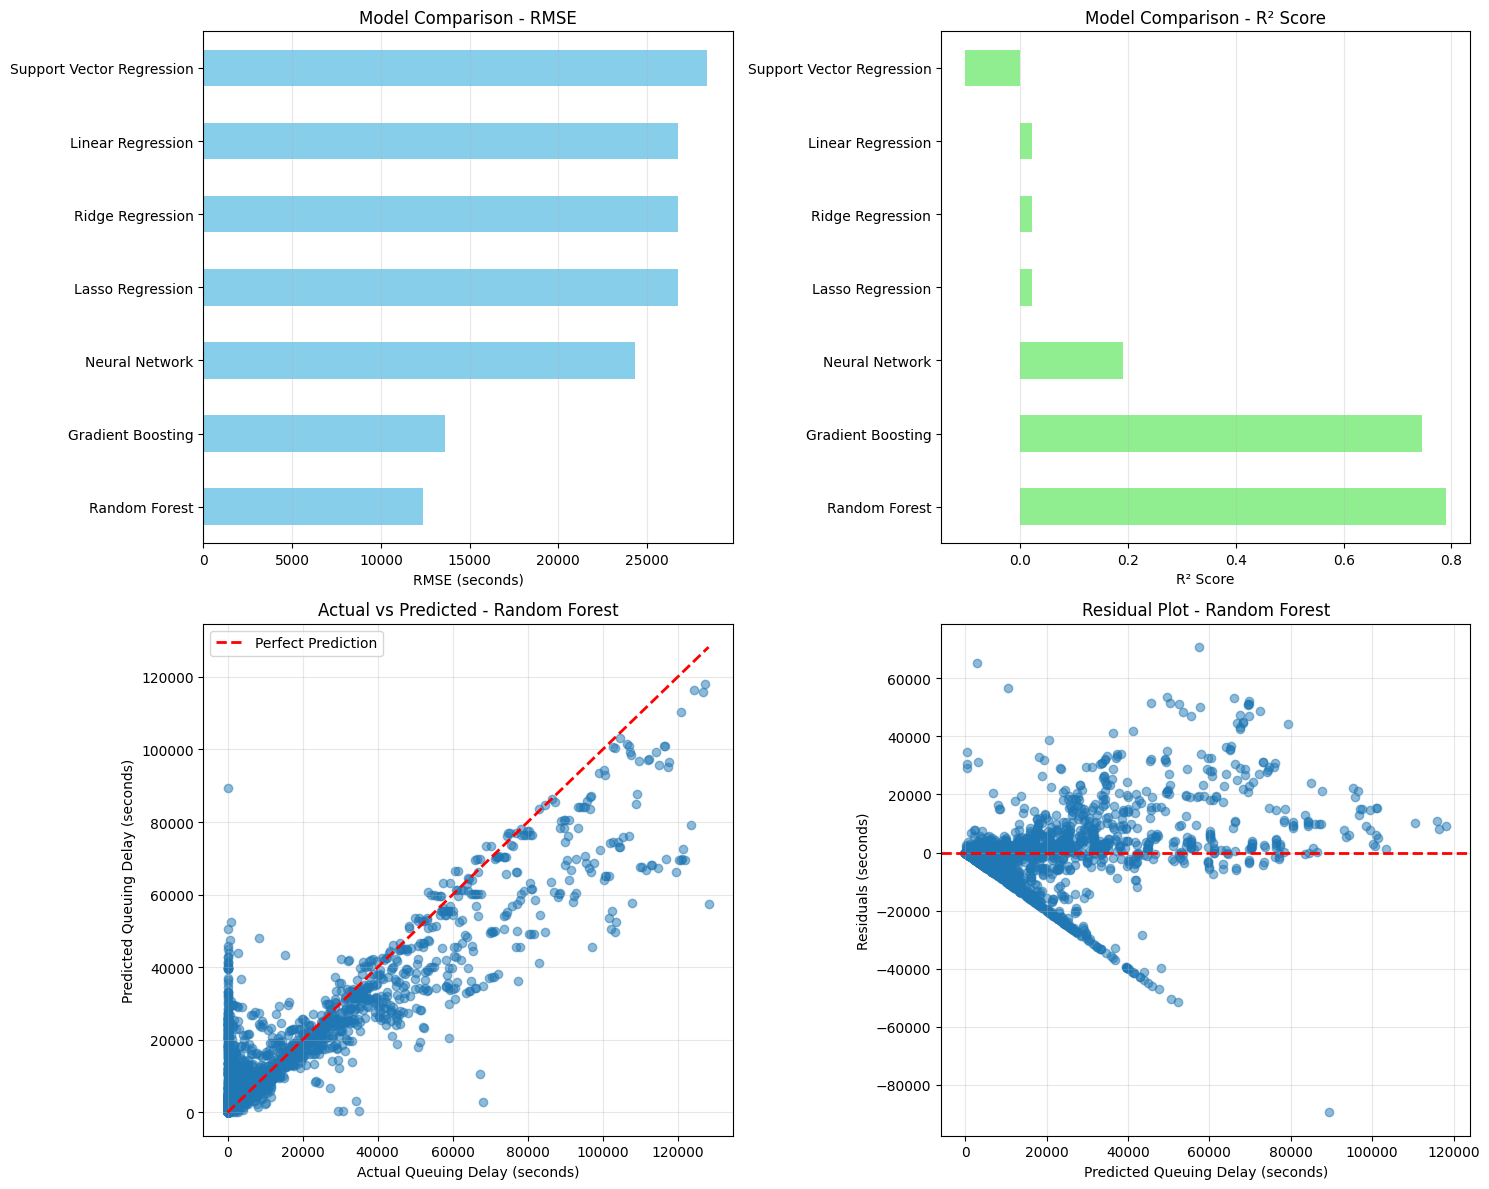

In [11]:
# Create results summary DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')

print("\n" + "="*50)
print("RESULTS SUMMARY (sorted by RMSE)")
print("="*50)
print(results_df)

# Find the best model
best_model_name = results_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f} seconds")
print(f"   MAE: {results_df.loc[best_model_name, 'MAE']:.2f} seconds")
print(f"   R²: {results_df.loc[best_model_name, 'R2']:.4f}")

# Feature importance for tree-based models
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

for name in ['Random Forest', 'Gradient Boosting']:
    if name in models:
        model = models[name]
        if name == 'Random Forest':
            model.fit(X_train, y_train)
        else:
            model.fit(X_train, y_train)
        
        importance_df = pd.DataFrame({
            'feature': feature_columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\n{name}:")
        print(importance_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model comparison
ax1 = axes[0, 0]
results_df['RMSE'].plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('RMSE (seconds)')
ax1.set_title('Model Comparison - RMSE')
ax1.grid(axis='x', alpha=0.3)

# 2. R² Score comparison
ax2 = axes[0, 1]
results_df['R2'].plot(kind='barh', ax=ax2, color='lightgreen')
ax2.set_xlabel('R² Score')
ax2.set_title('Model Comparison - R² Score')
ax2.grid(axis='x', alpha=0.3)

# 3. Actual vs Predicted for best model
ax3 = axes[1, 0]
best_predictions = predictions[best_model_name]
ax3.scatter(y_test, best_predictions, alpha=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Queuing Delay (seconds)')
ax3.set_ylabel('Predicted Queuing Delay (seconds)')
ax3.set_title(f'Actual vs Predicted - {best_model_name}')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Residuals plot
ax4 = axes[1, 1]
residuals = y_test - best_predictions
ax4.scatter(best_predictions, residuals, alpha=0.5)
ax4.axhline(y=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Predicted Queuing Delay (seconds)')
ax4.set_ylabel('Residuals (seconds)')
ax4.set_title(f'Residual Plot - {best_model_name}')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_with_outliers.pdf', dpi=300, bbox_inches='tight')

# Save results to CSV
results_df.to_csv('model_results_with_outliers.csv')

print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)


## Remove outliers and run again

In [12]:
df_no_outliers = df.copy()

for num_cores in [4, 16, 64]:
    mask = df_no_outliers['num_cores'] == num_cores
    subset = df_no_outliers.loc[mask, 'queuing_delay']
    
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only rows within bounds for this num_cores group
    valid = (subset >= lower_bound) & (subset <= upper_bound)
    df_no_outliers = df_no_outliers[~mask | valid]

df = df_no_outliers

In [13]:
feature_columns = [
    'num_cores',
    'jobs_ahead',
    'jobs_in_my_queue',
    'jobs_running',
    'hour',
    'day_of_week',
    'minute',
    'total_jobs',
    'queue_load'
]

X = df[feature_columns]
y = df['queuing_delay']

In [14]:
correlations = df[feature_columns + ['queuing_delay']].corr()['queuing_delay'].sort_values(ascending=False)
print(correlations)

queuing_delay       1.000000
hour                0.251516
jobs_in_my_queue    0.215788
queue_load          0.073429
total_jobs          0.073324
jobs_ahead          0.062272
minute              0.003394
day_of_week        -0.200422
jobs_running       -0.213038
num_cores                NaN
Name: queuing_delay, dtype: float64


In [15]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 7964
Test set size: 1991


In [16]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Support Vector Regression': SVR(kernel='rbf', C=100, gamma='scale'),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

In [17]:
# Train and evaluate models
results = {}
predictions = {}

print("\n" + "="*50)
print("MODEL TRAINING AND EVALUATION")
print("="*50)

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 40)
    
    # Use scaled data for models that benefit from scaling
    if name in ['Ridge Regression', 'Lasso Regression', 'Support Vector Regression', 'Neural Network']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     cv=5, scoring='neg_mean_squared_error')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, 
                                     cv=5, scoring='neg_mean_squared_error')
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_RMSE': np.sqrt(-cv_scores.mean())
    }
    predictions[name] = y_pred
    
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Cross-Validation RMSE: {np.sqrt(-cv_scores.mean()):.2f}")


MODEL TRAINING AND EVALUATION

Linear Regression:
----------------------------------------
Mean Squared Error (MSE): 243411994.07
Root Mean Squared Error (RMSE): 15601.67
Mean Absolute Error (MAE): 11874.33
R² Score: 0.1750
Cross-Validation RMSE: 14956.83

Ridge Regression:
----------------------------------------
Mean Squared Error (MSE): 243412396.90
Root Mean Squared Error (RMSE): 15601.68
Mean Absolute Error (MAE): 11874.44
R² Score: 0.1750
Cross-Validation RMSE: 14956.83

Lasso Regression:
----------------------------------------
Mean Squared Error (MSE): 243412536.62
Root Mean Squared Error (RMSE): 15601.68
Mean Absolute Error (MAE): 11874.55
R² Score: 0.1750
Cross-Validation RMSE: 14956.82

Random Forest:
----------------------------------------
Mean Squared Error (MSE): 38114915.00
Root Mean Squared Error (RMSE): 6173.73
Mean Absolute Error (MAE): 3366.13
R² Score: 0.8708
Cross-Validation RMSE: 6288.80

Gradient Boosting:
----------------------------------------
Mean Squared E


RESULTS SUMMARY (sorted by RMSE)
                                    MSE          RMSE           MAE        R2  \
Random Forest              3.811492e+07   6173.727804   3366.126034  0.870813   
Gradient Boosting          6.345298e+07   7965.737575   5061.502248  0.784933   
Neural Network             1.806205e+08  13439.513563   9937.669176  0.387806   
Linear Regression          2.434120e+08  15601.666388  11874.330314  0.174980   
Ridge Regression           2.434124e+08  15601.679297  11874.438632  0.174979   
Lasso Regression           2.434125e+08  15601.683775  11874.550127  0.174979   
Support Vector Regression  2.679720e+08  16369.851577  10036.631547  0.091737   

                                CV_RMSE  
Random Forest               6288.796670  
Gradient Boosting           7952.714533  
Neural Network             13415.852278  
Linear Regression          14956.834394  
Ridge Regression           14956.831452  
Lasso Regression           14956.816619  
Support Vector Regressi

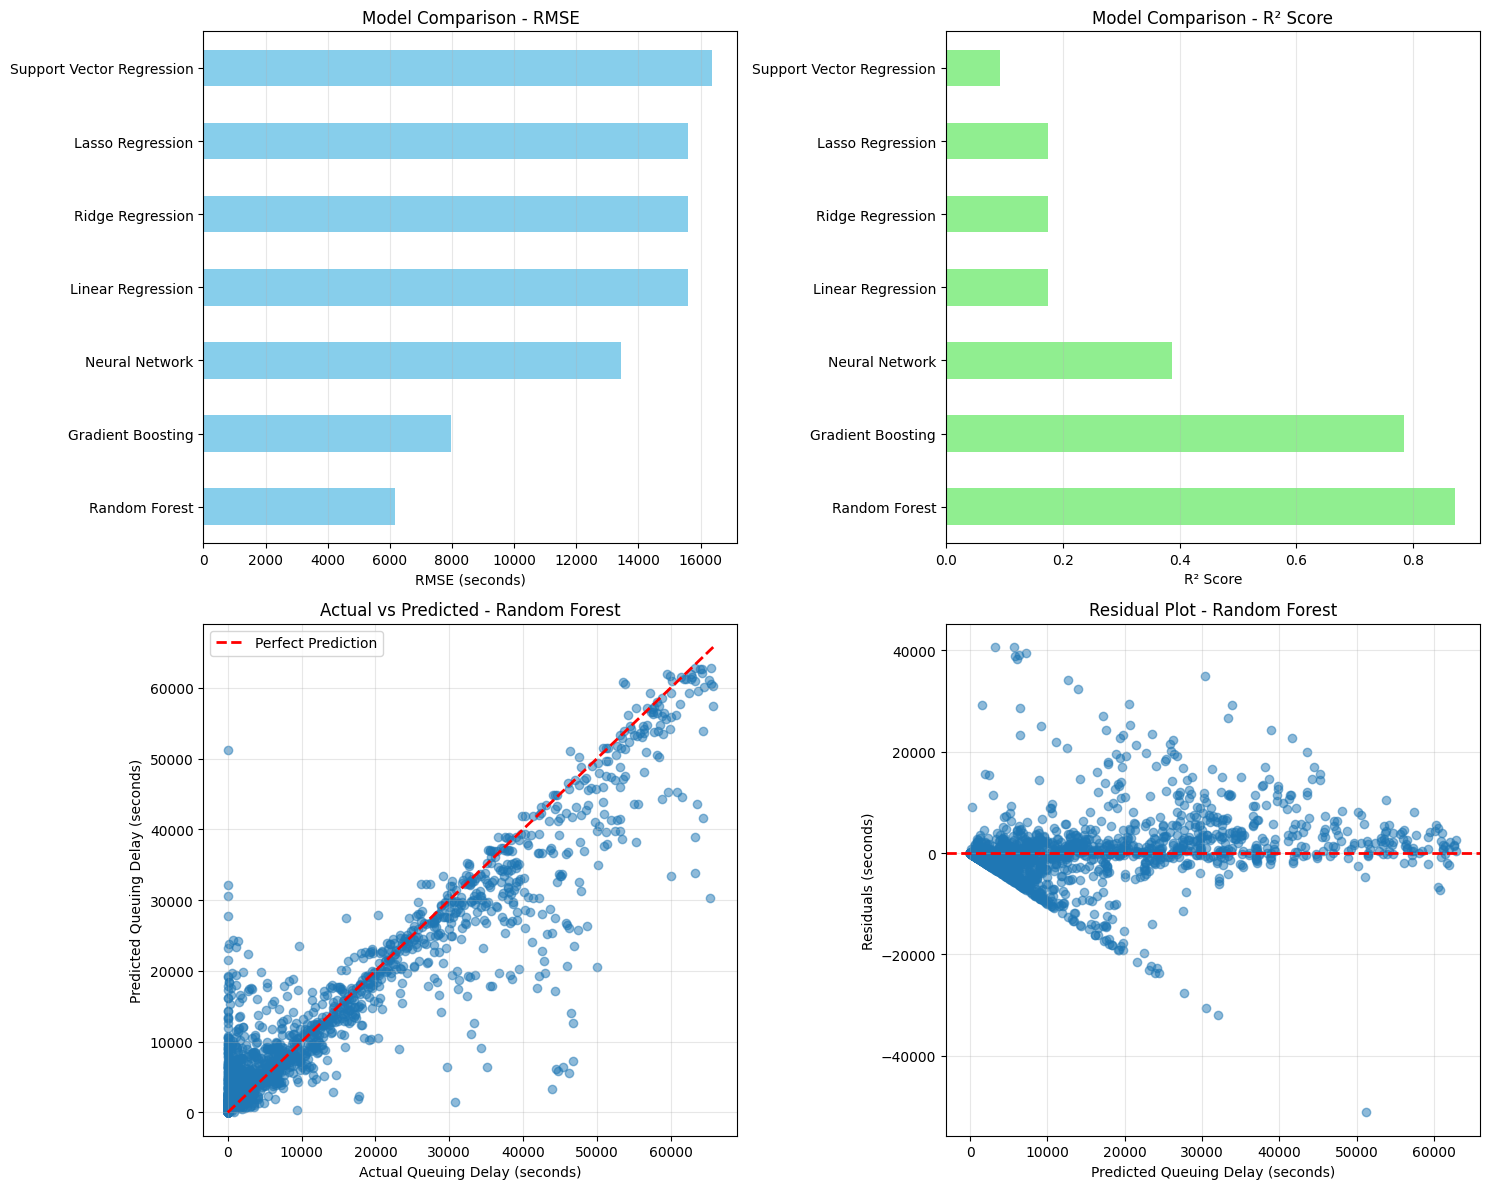

In [18]:
# Create results summary DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')

print("\n" + "="*50)
print("RESULTS SUMMARY (sorted by RMSE)")
print("="*50)
print(results_df)

# Find the best model
best_model_name = results_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f} seconds")
print(f"   MAE: {results_df.loc[best_model_name, 'MAE']:.2f} seconds")
print(f"   R²: {results_df.loc[best_model_name, 'R2']:.4f}")

# Feature importance for tree-based models
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

for name in ['Random Forest', 'Gradient Boosting']:
    if name in models:
        model = models[name]
        if name == 'Random Forest':
            model.fit(X_train, y_train)
        else:
            model.fit(X_train, y_train)
        
        importance_df = pd.DataFrame({
            'feature': feature_columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\n{name}:")
        print(importance_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model comparison
ax1 = axes[0, 0]
results_df['RMSE'].plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('RMSE (seconds)')
ax1.set_title('Model Comparison - RMSE')
ax1.grid(axis='x', alpha=0.3)

# 2. R² Score comparison
ax2 = axes[0, 1]
results_df['R2'].plot(kind='barh', ax=ax2, color='lightgreen')
ax2.set_xlabel('R² Score')
ax2.set_title('Model Comparison - R² Score')
ax2.grid(axis='x', alpha=0.3)

# 3. Actual vs Predicted for best model
ax3 = axes[1, 0]
best_predictions = predictions[best_model_name]
ax3.scatter(y_test, best_predictions, alpha=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Queuing Delay (seconds)')
ax3.set_ylabel('Predicted Queuing Delay (seconds)')
ax3.set_title(f'Actual vs Predicted - {best_model_name}')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Residuals plot
ax4 = axes[1, 1]
residuals = y_test - best_predictions
ax4.scatter(best_predictions, residuals, alpha=0.5)
ax4.axhline(y=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Predicted Queuing Delay (seconds)')
ax4.set_ylabel('Residuals (seconds)')
ax4.set_title(f'Residual Plot - {best_model_name}')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_no_outliers.pdf', dpi=300, bbox_inches='tight')

# Save results to CSV
results_df.to_csv('model_results_no_outliers.csv')

print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)
